In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

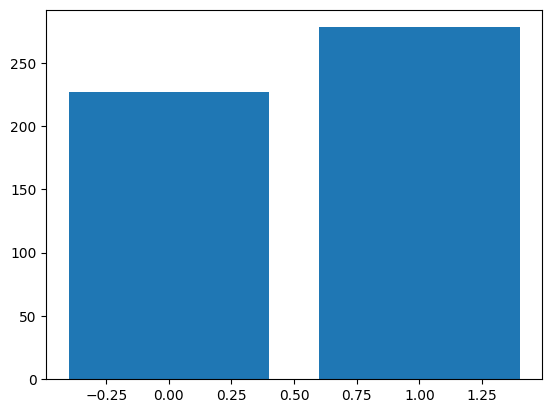

In [70]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X= train_df.drop(columns=['id', 'powerstats__combat', 'Super Strength'])
y= train_df[['powerstats__combat', 'Super Strength']]

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify= y['Super Strength'], random_state= seed)

X_test= test_df.drop(columns=['id'])

plt.bar(np.unique_counts(train_df['Super Strength']).values, np.unique_counts(train_df['Super Strength']).counts)
plt.show()

In [71]:
# Subtask 1

answer1= []

answer1.append({
    'id': 'GLOBAL',
    'subtaskID': 'task1',
    'answer': len(np.unique(train_df['Publisher']))
})

answer1= pd.DataFrame(answer1)
answer1.head()

,id,subtaskID,answer
0,GLOBAL,task1,23


In [72]:
# Subtask 2

answer2= []

answer2.append({
    'id': 'GLOBAL',
    'subtaskID': 'task2',
    'answer': train_df[train_df['Alignment']== 'good']['Publisher'].value_counts().index[0]
})

answer2= pd.DataFrame(answer2)
answer2.head()

,id,subtaskID,answer
0,GLOBAL,task2,Marvel Comics


In [73]:
#Subtask 3
from xgboost import XGBRegressor

X_train_enc = pd.get_dummies(X_train)
X_eval_enc = pd.get_dummies(X_eval)
X_test_enc = pd.get_dummies(X_test)

X_train_enc, X_eval_enc = X_train_enc.align(X_eval_enc, join='left', axis=1, fill_value=0)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=seed
)

model.fit(
    X_train_enc, y_train['powerstats__combat'],
    eval_set=[(X_eval_enc, y_eval['powerstats__combat'])],
    verbose=200
)

predictions_xgb= model.predict(X_test_enc)

[0]	validation_0-rmse:31.61371
[200]	validation_0-rmse:18.79110
[400]	validation_0-rmse:18.79309
[600]	validation_0-rmse:18.86447
[800]	validation_0-rmse:18.86916
[999]	validation_0-rmse:18.86746


In [74]:
from catboost import CatBoostRegressor

cat_cols= X.select_dtypes(include=['object', 'string']).columns.to_list()

for col in cat_cols:
    X_train[col] = X_train[col].astype('string').fillna('missing')
    X_eval[col] = X_eval[col].astype('string').fillna('missing')
    X_test[col] = X_test[col].astype('string').fillna('missing')

model= CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    loss_function='MAE',
    eval_metric='MAE',
    early_stopping_rounds=200,
    cat_features=cat_cols,
    random_state= seed
)

model.fit(
    X_train, y_train['powerstats__combat'],
    eval_set=[(X_eval, y_eval['powerstats__combat'])],
    verbose= 200
)

predictions_cat= model.predict(X_test)

0:	learn: 23.6680683	test: 26.5613851	best: 26.5613851 (0)	total: 16.3ms	remaining: 16.3s
200:	learn: 6.1221668	test: 13.8969731	best: 13.8636934 (167)	total: 2.9s	remaining: 11.5s
400:	learn: 3.4440822	test: 13.9804425	best: 13.8635050 (211)	total: 5.84s	remaining: 8.72s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 13.86350501
bestIteration = 211

Shrink model to first 212 iterations.


In [75]:
answer3= []

for id_, idx in zip(test_df['id'], range(len(test_df))):
    answer3.append({
        'id': id_,
        'subtaskID': 'task3',
        'answer': predictions_xgb[idx]* 0.5 + predictions_cat[idx]* 0.5
    })

answer3= pd.DataFrame(answer3)
answer3.head(5)

,id,subtaskID,answer
0,560,task3,76.756775
1,626,task3,62.128368
2,486,task3,50.497102
3,45,task3,39.831565
4,59,task3,79.166971


In [76]:
#subtask 4

from catboost import CatBoostClassifier

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    early_stopping_rounds=200,
    cat_features=cat_cols,
    random_state= seed
)

model.fit(
    X_train, y_train['Super Strength'],
    eval_set=[(X_eval, y_eval['Super Strength'])],
    verbose= 200
)

predictions= model.predict(X_test)

answer4= []

for id_, pred in zip(test_df['id'], predictions):
    answer4.append({
        'id': id_,
        'subtaskID': 'task4',
        'answer': pred
    })

answer4= pd.DataFrame(answer4)
answer4.head(5)

0:	learn: 0.6727311	test: 0.6788919	best: 0.6788919 (0)	total: 14.8ms	remaining: 44.4s
200:	learn: 0.1425472	test: 0.3191996	best: 0.3190892 (199)	total: 3.33s	remaining: 46.4s
400:	learn: 0.0625837	test: 0.3034891	best: 0.3034891 (400)	total: 6.87s	remaining: 44.5s
600:	learn: 0.0373406	test: 0.3057921	best: 0.3026934 (439)	total: 10.5s	remaining: 41.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.3026934388
bestIteration = 439

Shrink model to first 440 iterations.


,id,subtaskID,answer
0,560,task4,1
1,626,task4,0
2,486,task4,0
3,45,task4,0
4,59,task4,1


In [77]:
answer= pd.concat([answer1, answer2, answer3, answer4])
answer.to_csv('submission.csv', index= False)